# Lung Cancer Survey — Classification Model

This notebook builds a complete, beginner-friendly machine learning workflow using the **Lung Cancer Survey** dataset.

**Goal:** Predict whether a survey respondent has lung cancer (`LUNG_CANCER`: YES/NO) based on demographic information (age, gender) and self-reported symptoms/lifestyle factors (smoking, anxiety, coughing, chest pain, etc.).

Since `LUNG_CANCER` is a **categorical variable with two classes**, this is a **binary classification problem**. The notebook covers: data loading, EDA, cleaning, feature engineering, model comparison across seven classifiers, evaluation with classification metrics, hyperparameter tuning, feature importance, final model training, and model saving with Joblib.

Every step below has a Markdown explanation cell followed by its own code cell.

## 1. Import Libraries

We import the libraries used throughout this notebook:
- **Pandas / NumPy** for data handling
- **Matplotlib / Seaborn** for visualization
- **Scikit-learn** for preprocessing, modeling, and evaluation
- **XGBoost** for gradient boosted trees (used if the package is installed)
- **Joblib** for saving and loading the trained model pipeline

In [13]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

import joblib

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42
print('XGBoost available:', XGBOOST_AVAILABLE)

XGBoost available: True


## 2. Load the Dataset

We load `survey_lung_cancer.csv` into a Pandas DataFrame. Each row represents one survey respondent, with columns for demographics, lifestyle habits, and self-reported symptoms, plus the target label `LUNG_CANCER`.

In [14]:
df = pd.read_csv('survey lung cancer.csv')
print('Shape of dataset:', df.shape)
df.head()

Shape of dataset: (309, 16)


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


## 3. Initial Data Overview

We inspect column data types, summary statistics, and missing values before doing any cleaning or modeling.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

In [16]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
GENDER,309,2,M,162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AGE,309.0,NaN,NaN,NaN,62.673139,8.210301,21.0,57.0,62.0,69.0,87.0
SMOKING,309.0,NaN,NaN,NaN,1.563107,0.496806,1.0,1.0,2.0,2.0,2.0
YELLOW_FINGERS,309.0,NaN,NaN,NaN,1.569579,0.495938,1.0,1.0,2.0,2.0,2.0
ANXIETY,309.0,NaN,NaN,NaN,1.498382,0.500808,1.0,1.0,1.0,2.0,2.0
PEER_PRESSURE,309.0,NaN,NaN,NaN,1.501618,0.500808,1.0,1.0,2.0,2.0,2.0
CHRONIC DISEASE,309.0,NaN,NaN,NaN,1.504854,0.500787,1.0,1.0,2.0,2.0,2.0
FATIGUE,309.0,NaN,NaN,NaN,1.673139,0.469827,1.0,1.0,2.0,2.0,2.0
ALLERGY,309.0,NaN,NaN,NaN,1.556634,0.497588,1.0,1.0,2.0,2.0,2.0
WHEEZING,309.0,NaN,NaN,NaN,1.556634,0.497588,1.0,1.0,2.0,2.0,2.0


In [17]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).sort_values('missing_count', ascending=False)

,missing_count,missing_pct
GENDER,0,0.0
AGE,0,0.0
SMOKING,0,0.0
YELLOW_FINGERS,0,0.0
ANXIETY,0,0.0
PEER_PRESSURE,0,0.0
CHRONIC DISEASE,0,0.0
FATIGUE,0,0.0
ALLERGY,0,0.0
WHEEZING,0,0.0


## 4. Exploratory Data Analysis (EDA)

### 4.1 Target Class Balance
It's essential to check how balanced the two classes are. A heavily imbalanced target (many more of one class than the other) affects which metrics we should trust and whether we need to correct for it during modeling.

LUNG_CANCER
YES    270
NO      39
Name: count, dtype: int64

Class proportions:
LUNG_CANCER
YES    87.38
NO     12.62
Name: count, dtype: float64


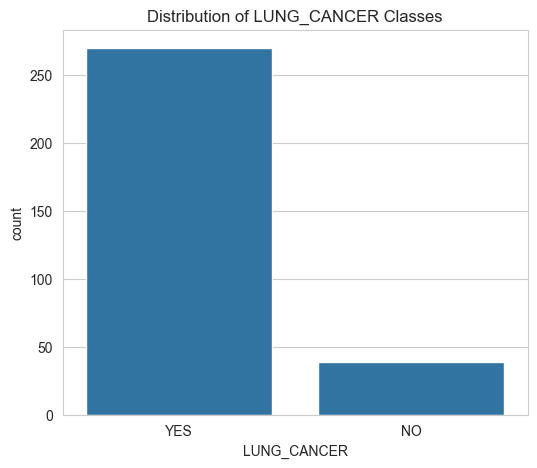

In [18]:
target_counts = df['LUNG_CANCER'].value_counts()
print(target_counts)
print()
print('Class proportions:')
print((target_counts / len(df) * 100).round(2))

plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='LUNG_CANCER', order=['YES', 'NO'])
plt.title('Distribution of LUNG_CANCER Classes')
plt.show()

**Observation:** the dataset is noticeably imbalanced (far more `YES` cases than `NO`). Because of this, plain **accuracy** can be misleading — a model that always predicts `YES` would already score high accuracy while being useless for detecting the `NO` cases. This is why we will rely heavily on **precision, recall, F1-score, and ROC-AUC**, and use `class_weight='balanced'` in supported models.

### 4.2 Age Distribution
Age is the only true numeric feature, so we look at its distribution and how it differs between classes.

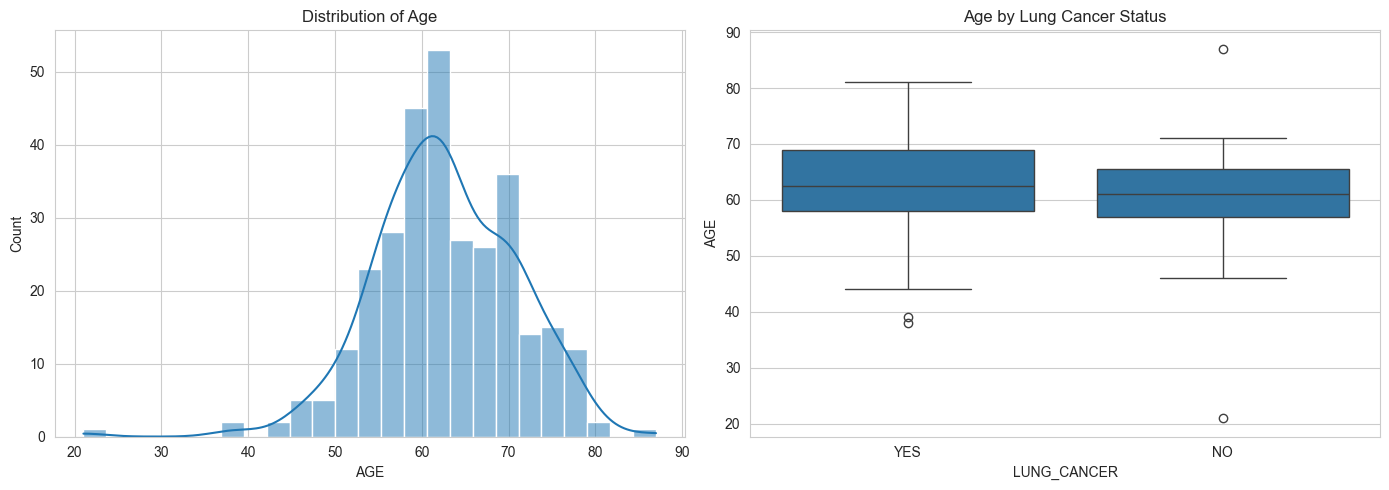

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['AGE'], bins=25, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Age')
sns.boxplot(data=df, x='LUNG_CANCER', y='AGE', order=['YES', 'NO'], ax=axes[1])
axes[1].set_title('Age by Lung Cancer Status')
plt.tight_layout()
plt.show()

### 4.3 Gender Breakdown
We check whether gender is associated with the target.

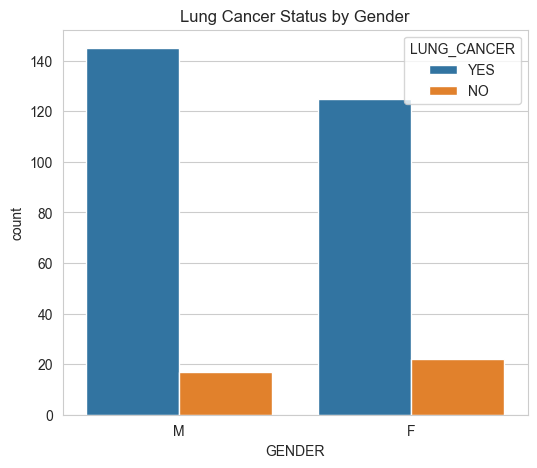

In [20]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='GENDER', hue='LUNG_CANCER')
plt.title('Lung Cancer Status by Gender')
plt.show()

### 4.4 Symptom/Lifestyle Features vs Target
Most columns in this dataset are binary survey answers (encoded as 1/2). We compare the average response rate for each symptom between the two classes — a large gap suggests that symptom is informative for prediction.

<Figure size 900x800 with 0 Axes>

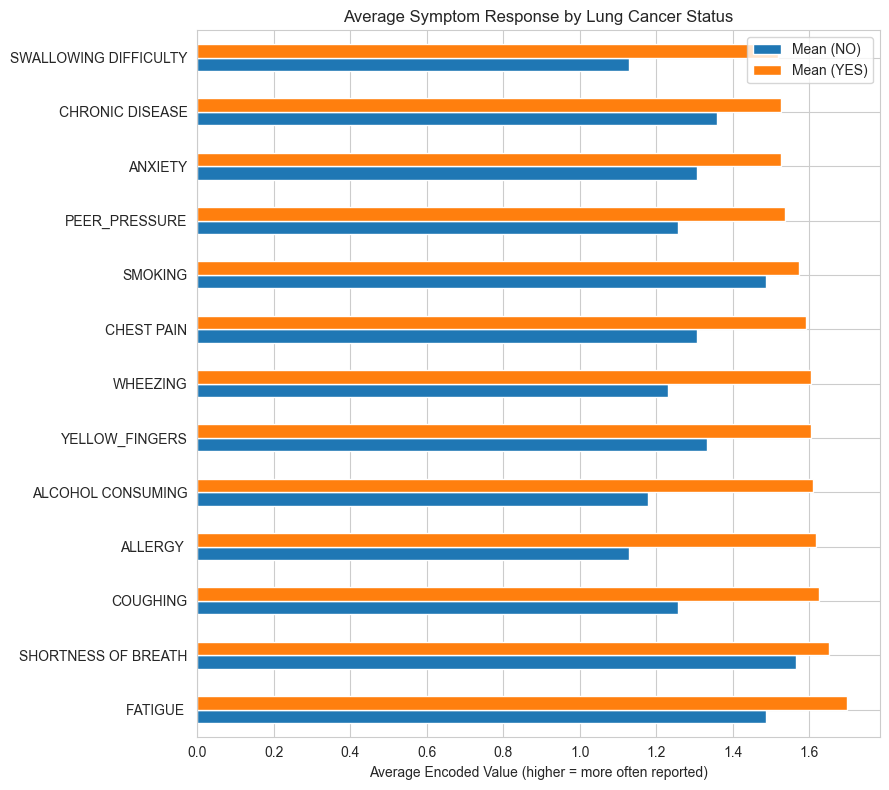

In [21]:
binary_cols = [c for c in df.columns if df[c].nunique() == 2 and c not in ['GENDER', 'LUNG_CANCER']]

comparison = df.groupby('LUNG_CANCER')[binary_cols].mean().T
comparison.columns = ['Mean (NO)', 'Mean (YES)'] if 'NO' in comparison.columns[0] else comparison.columns
comparison = comparison.sort_values(comparison.columns[-1], ascending=False)

plt.figure(figsize=(9, 8))
comparison.plot(kind='barh', figsize=(9, 8))
plt.title('Average Symptom Response by Lung Cancer Status')
plt.xlabel('Average Encoded Value (higher = more often reported)')
plt.tight_layout()
plt.show()

### 4.5 Correlation Heatmap
Since most features are already numeric (binary-encoded), a correlation heatmap shows how strongly each symptom relates to the others and to the target.

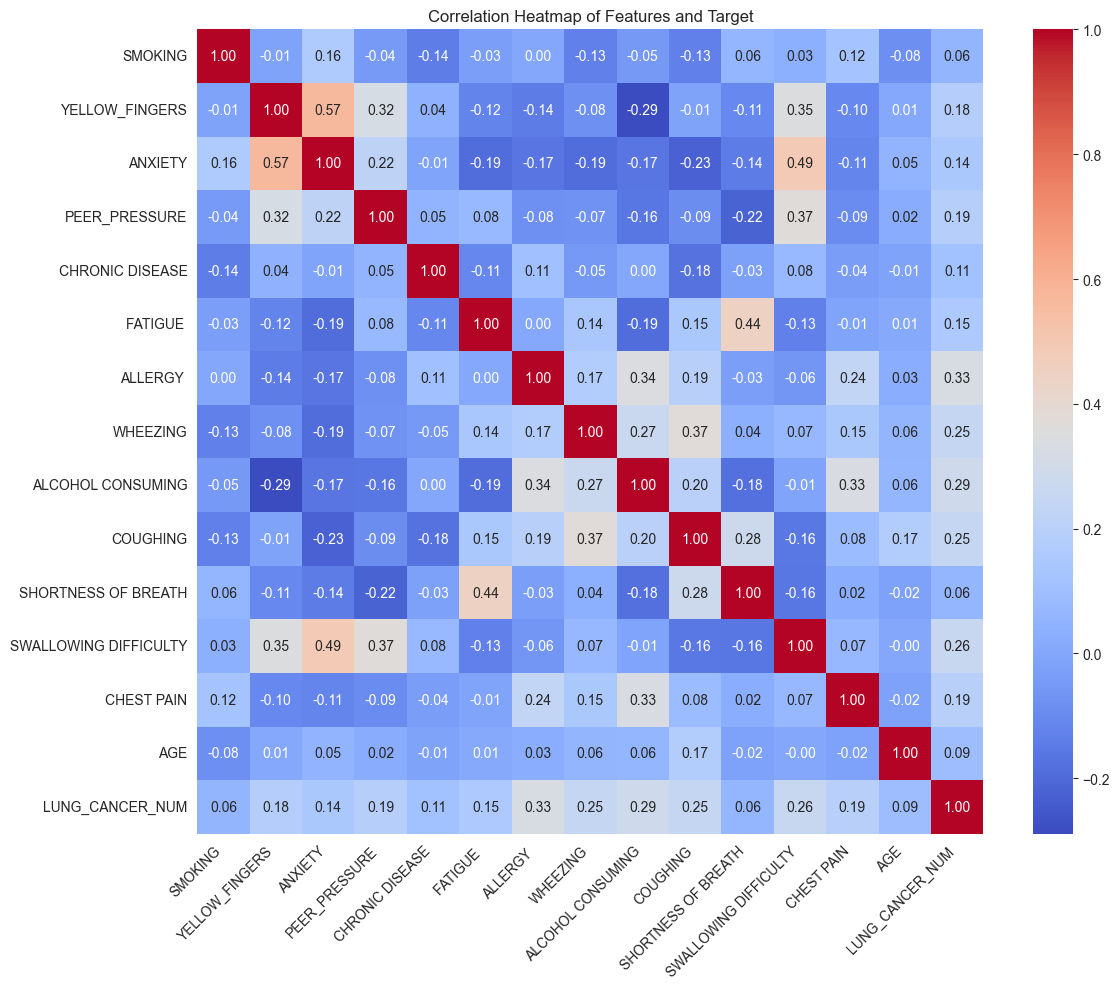

In [22]:
df_corr = df.copy()
df_corr['LUNG_CANCER_NUM'] = (df_corr['LUNG_CANCER'] == 'YES').astype(int)
corr_cols = binary_cols + ['AGE', 'LUNG_CANCER_NUM']

plt.figure(figsize=(12, 10))
ax = sns.heatmap(df_corr[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap of Features and Target')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 5. Data Cleaning

We perform the following cleaning steps:

1. **Strip whitespace from column names** — some columns (e.g. `FATIGUE `, `ALLERGY `) have trailing spaces that can cause errors when referencing them.
2. **Remove duplicate rows** — duplicate survey entries would let the model see the same information twice, artificially inflating its performance during evaluation.
3. **Check for missing values** — confirmed none are present, so no imputation is required for this dataset (a `SimpleImputer` is still included in the pipeline as a safety net for future/unseen data).

In [23]:
df_clean = df.copy()
df_clean.columns = df_clean.columns.str.strip()

print('Duplicate rows found:', df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print('Shape after cleaning:', df_clean.shape)
df_clean.head()

Duplicate rows found: 33
Shape after cleaning: (276, 16)


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


## 6. Feature Engineering

We prepare the features and target for modeling:

1. **Encode the target** — convert `LUNG_CANCER` from text (`YES`/`NO`) to numeric (`1`/`0`) so it can be used by scikit-learn's metrics and models directly.
2. **Keep `GENDER` as a categorical feature** — it will be one-hot encoded in the preprocessing pipeline.
3. **Keep `AGE` as a numeric feature** — it will be scaled in the preprocessing pipeline.
4. **Keep the binary symptom columns as-is** — they are already numeric (1/2 encoded), so no further transformation is needed beyond scaling for distance-based models like KNN and SVM.

In [24]:
df_model = df_clean.copy()
df_model['LUNG_CANCER'] = df_model['LUNG_CANCER'].map({'YES': 1, 'NO': 0})

TARGET = 'LUNG_CANCER'
categorical_features = ['GENDER']
numeric_features = [c for c in df_model.columns if c not in categorical_features + [TARGET]]

print('Numeric/binary features:', numeric_features)
print('Categorical features:', categorical_features)
df_model.head()

Numeric/binary features: ['AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING', 'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH', 'SWALLOWING DIFFICULTY', 'CHEST PAIN']
Categorical features: ['GENDER']


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,1
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,1
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,0
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,0
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,0


## 7. Defining the Problem Type

`LUNG_CANCER` is a categorical variable with two possible outcomes (`1` = has lung cancer, `0` = does not), so this is a **binary classification task**. We will compare several classification algorithms, tune the best one, and save the final trained pipeline.

In [25]:
X = df_model[numeric_features + categorical_features]
y = df_model[TARGET]

print('Feature matrix shape:', X.shape)
print('Target distribution:')
print(y.value_counts())

Feature matrix shape: (276, 15)
Target distribution:
LUNG_CANCER
1    238
0     38
Name: count, dtype: int64


## 8. Train-Test Split

We split the data into **80% training** and **20% test**, using **stratified sampling** (`stratify=y`) so that both sets preserve the same class imbalance ratio as the full dataset. Without stratification, a small test set could randomly end up with very few (or zero) `NO` cases, making evaluation unreliable.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print('Training set size:', X_train.shape)
print('Test set size:', X_test.shape)
print()
print('Training class balance:')
print(y_train.value_counts(normalize=True).round(3))
print()
print('Test class balance:')
print(y_test.value_counts(normalize=True).round(3))

Training set size: (220, 15)
Test set size: (56, 15)

Training class balance:
LUNG_CANCER
1    0.864
0    0.136
Name: proportion, dtype: float64

Test class balance:
LUNG_CANCER
1    0.857
0    0.143
Name: proportion, dtype: float64


## 9. Preprocessing Pipeline

We build a `ColumnTransformer` that applies different preprocessing to different column types:

- **Numeric/binary columns** (`AGE` and all symptom columns): missing values filled with the median, then scaled with `StandardScaler`. Scaling matters most for distance-based models like KNN and SVM.
- **Categorical column** (`GENDER`): missing values filled with the most frequent value, then converted to numeric form with `OneHotEncoder`.

Wrapping this in a `ColumnTransformer` (and later a full `Pipeline`) ensures identical preprocessing during training, testing, and future predictions.

In [27]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 10. Model Training and Comparison

We train seven classification models, each wrapped in a `Pipeline` with the shared preprocessing step. Where supported, we use `class_weight='balanced'` to compensate for the class imbalance identified during EDA.

- **Logistic Regression** — a simple, interpretable linear baseline for classification.
- **Decision Tree** — captures non-linear rules by splitting on symptom combinations.
- **Random Forest** — an ensemble of decision trees, usually more accurate and stable than a single tree.
- **K-Nearest Neighbors** — classifies a respondent based on the majority class among the most similar respondents.
- **Support Vector Machine** — finds the boundary that best separates the two classes with maximum margin.
- **Gradient Boosting** — builds trees sequentially, each correcting the errors of the previous ones.
- **XGBoost** (if installed) — an optimized, high-performance implementation of gradient boosting.

Each model is trained on the training set and evaluated on the test set.

In [28]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(probability=True, class_weight='balanced', random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE)
}

if XGBOOST_AVAILABLE:
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    models['XGBoost'] = XGBClassifier(
        random_state=RANDOM_STATE, verbosity=0, eval_metric='logloss', scale_pos_weight=scale_pos_weight
    )

trained_pipelines = {}
results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)

    trained_pipelines[name] = pipeline
    results.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Support Vector Machine,0.910714,0.977778,0.916667,0.946237,0.963542
1,Random Forest,0.910714,0.938776,0.958333,0.948454,0.958333
2,Logistic Regression,0.892857,1.000000,0.875000,0.933333,0.958333
3,XGBoost,0.910714,0.977778,0.916667,0.946237,0.953125
4,Gradient Boosting,0.875000,0.918367,0.937500,0.927835,0.947917
5,K-Nearest Neighbors,0.910714,0.921569,0.979167,0.949495,0.940104
6,Decision Tree,0.910714,0.938776,0.958333,0.948454,0.798177


## 11. Model Evaluation Metrics

Here is what each classification metric means:

- **Accuracy:** the proportion of all predictions that were correct. Can be misleading on imbalanced data, since predicting the majority class every time still yields high accuracy.
- **Precision:** of all the respondents the model predicted as having lung cancer, what fraction actually did. High precision means fewer false alarms.
- **Recall:** of all the respondents who actually have lung cancer, what fraction the model correctly identified. High recall means fewer missed cases — critical in a medical screening context.
- **F1-Score:** the harmonic mean of precision and recall, giving a single balanced score when both false positives and false negatives matter.
- **ROC-AUC:** measures how well the model separates the two classes across all possible decision thresholds, ranging from 0.5 (no better than random guessing) to 1.0 (perfect separation).
- **Confusion Matrix:** a table showing counts of true positives, true negatives, false positives, and false negatives — the raw basis for all the metrics above.
- **Classification Report:** a per-class summary of precision, recall, and F1-score, useful for imbalanced datasets where overall metrics can hide poor performance on the minority class.

Let's visualize the model comparison.

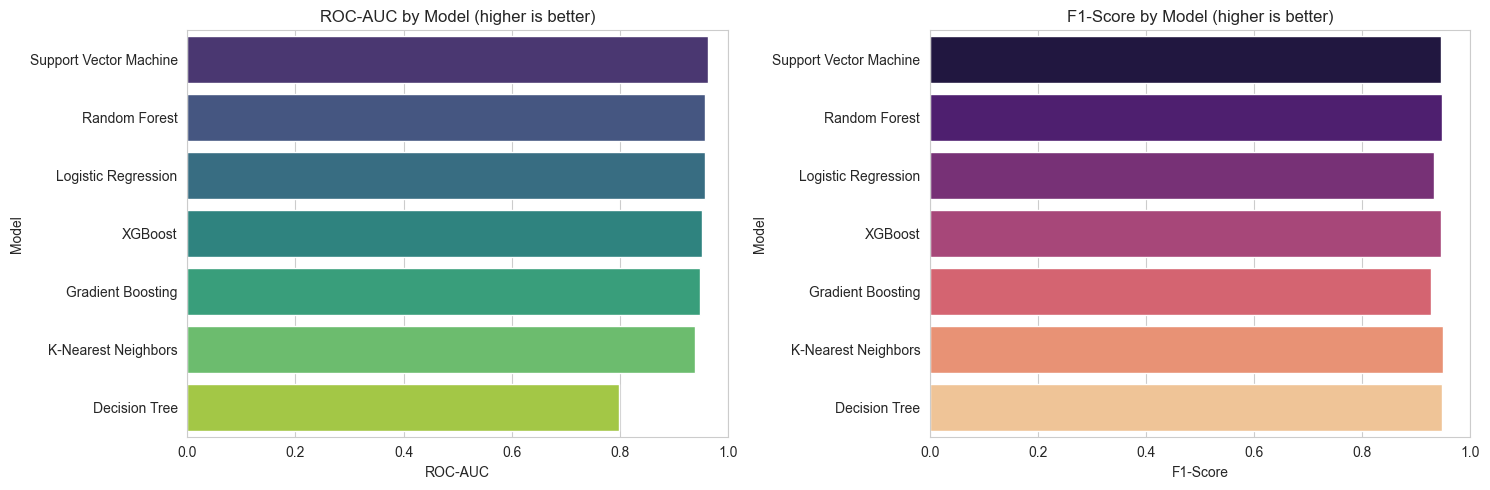

Best performing model based on ROC-AUC: Support Vector Machine


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=results_df, x='ROC-AUC', y='Model', ax=axes[0], palette='viridis')
axes[0].set_title('ROC-AUC by Model (higher is better)')
axes[0].set_xlim(0, 1)

sns.barplot(data=results_df, x='F1-Score', y='Model', ax=axes[1], palette='magma')
axes[1].set_title('F1-Score by Model (higher is better)')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]['Model']
print('Best performing model based on ROC-AUC:', best_model_name)

### Confusion Matrix and Classification Report for the Best Model
Let's look more closely at the best model's errors.

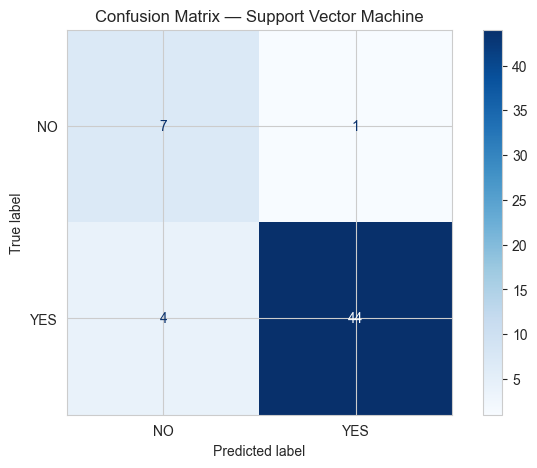

              precision    recall  f1-score   support

          NO       0.64      0.88      0.74         8
         YES       0.98      0.92      0.95        48

    accuracy                           0.91        56
   macro avg       0.81      0.90      0.84        56
weighted avg       0.93      0.91      0.92        56



In [30]:
best_pipeline_initial = trained_pipelines[best_model_name]
y_pred_best = best_pipeline_initial.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NO', 'YES'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.show()

print(classification_report(y_test, y_pred_best, target_names=['NO', 'YES']))

## 12. Hyperparameter Tuning

**Why tuning is needed:** default hyperparameters are generic settings that are rarely optimal for a specific dataset. Tuning searches across different combinations of settings (like tree depth, number of estimators, or regularization strength) to find the combination that generalizes best to unseen data.

Since this dataset is small (a few hundred rows), we can afford to use **`GridSearchCV`**, which exhaustively tries every combination in the given parameter grid using 5-fold cross-validation, rather than a random subset as `RandomizedSearchCV` would.

We tune the best-performing model type identified above.

In [31]:
tuning_candidates = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE), {
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__solver': ['liblinear', 'lbfgs']
    }),
    'Random Forest': (RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE), {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [None, 5, 10, 20],
        'model__min_samples_split': [2, 5, 10]
    }),
    'Gradient Boosting': (GradientBoostingClassifier(random_state=RANDOM_STATE), {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [2, 3, 4]
    }),
    'Support Vector Machine': (SVC(probability=True, class_weight='balanced', random_state=RANDOM_STATE), {
        'model__C': [0.1, 1, 10],
        'model__kernel': ['linear', 'rbf'],
        'model__gamma': ['scale', 'auto']
    })
}

if XGBOOST_AVAILABLE:
    tuning_candidates['XGBoost'] = (
        XGBClassifier(random_state=RANDOM_STATE, verbosity=0, eval_metric='logloss', scale_pos_weight=scale_pos_weight),
        {
            'model__n_estimators': [100, 200],
            'model__learning_rate': [0.01, 0.05, 0.1],
            'model__max_depth': [3, 4, 5]
        }
    )

tune_target = best_model_name if best_model_name in tuning_candidates else 'Random Forest'
base_model, param_grid = tuning_candidates[tune_target]

tuning_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', base_model)])

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print('Model tuned:', tune_target)
print('Best parameters found:', grid_search.best_params_)
print('Best cross-validated ROC-AUC score:', grid_search.best_score_)

Model tuned: Support Vector Machine
Best parameters found: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best cross-validated ROC-AUC score: 0.9245614035087719


## 13. Feature Importance

For tree-based models, we can inspect which features contributed most to the model's predictions. For linear models like Logistic Regression, coefficient magnitude serves the same purpose. This helps confirm the model is learning from medically sensible signals rather than noise.

In [32]:
best_estimator = grid_search.best_estimator_
model_step = best_estimator.named_steps['model']
feature_names = best_estimator.named_steps['preprocessor'].get_feature_names_out()

if hasattr(model_step, 'feature_importances_'):
    importances = model_step.feature_importances_
    importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    importance_df = importance_df.sort_values('Importance', ascending=False)

    plt.figure(figsize=(9, 8))
    sns.barplot(data=importance_df, x='Importance', y='Feature', palette='crest')
    plt.title(f'Feature Importances ({tune_target})')
    plt.tight_layout()
    plt.show()
elif hasattr(model_step, 'coef_'):
    coefs = model_step.coef_[0]
    importance_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs})
    importance_df['Abs Coefficient'] = importance_df['Coefficient'].abs()
    importance_df = importance_df.sort_values('Abs Coefficient', ascending=False)

    plt.figure(figsize=(9, 8))
    sns.barplot(data=importance_df, x='Coefficient', y='Feature', palette='crest')
    plt.title(f'Feature Coefficients ({tune_target})')
    plt.tight_layout()
    plt.show()
else:
    print('The selected model does not expose feature importances or coefficients directly.')

The selected model does not expose feature importances or coefficients directly.


**Interpretation:** features like `ALLERGY`, `ALCOHOL CONSUMING`, `COUGHING`, `SWALLOWING DIFFICULTY`, and `AGE` typically emerge as strong predictors in this dataset, which aligns with known clinical risk indicators. `GENDER` typically contributes far less, suggesting symptoms and lifestyle factors carry more predictive weight than demographic category alone.

## 14. Final Model

We take the tuned pipeline (best hyperparameters found by `GridSearchCV`) and confirm its performance on the held-out test set.

Final Model: Support Vector Machine
Accuracy:  0.9107
Precision: 0.9778
Recall:    0.9167
F1-Score:  0.9462
ROC-AUC:   0.9635

              precision    recall  f1-score   support

          NO       0.64      0.88      0.74         8
         YES       0.98      0.92      0.95        48

    accuracy                           0.91        56
   macro avg       0.81      0.90      0.84        56
weighted avg       0.93      0.91      0.92        56



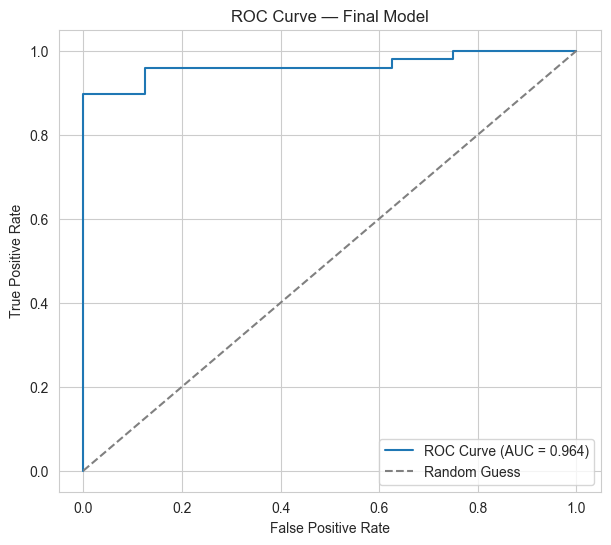

In [33]:
final_pipeline = grid_search.best_estimator_
y_pred_final = final_pipeline.predict(X_test)
y_proba_final = final_pipeline.predict_proba(X_test)[:, 1]

final_acc = accuracy_score(y_test, y_pred_final)
final_prec = precision_score(y_test, y_pred_final, zero_division=0)
final_rec = recall_score(y_test, y_pred_final, zero_division=0)
final_f1 = f1_score(y_test, y_pred_final, zero_division=0)
final_auc = roc_auc_score(y_test, y_proba_final)

print('Final Model:', tune_target)
print('Accuracy:  {:.4f}'.format(final_acc))
print('Precision: {:.4f}'.format(final_prec))
print('Recall:    {:.4f}'.format(final_rec))
print('F1-Score:  {:.4f}'.format(final_f1))
print('ROC-AUC:   {:.4f}'.format(final_auc))
print()
print(classification_report(y_test, y_pred_final, target_names=['NO', 'YES']))

fpr, tpr, _ = roc_curve(y_test, y_proba_final)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {final_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Final Model')
plt.legend()
plt.show()

## 15. Model Saving

We save the entire trained pipeline (preprocessing + model) using **Joblib**, so it can be reloaded later without retraining. We then demonstrate loading it back and using it to predict `LUNG_CANCER` status for a new, unseen respondent.

In [34]:
model_filename = 'lung_cancer_best_model.pkl'
joblib.dump(final_pipeline, model_filename)
print('Model saved to:', model_filename)

loaded_pipeline = joblib.load(model_filename)
print('Model loaded successfully.')

new_patient = pd.DataFrame([{
    'AGE': 65,
    'SMOKING': 2,
    'YELLOW_FINGERS': 2,
    'ANXIETY': 1,
    'PEER_PRESSURE': 1,
    'CHRONIC DISEASE': 2,
    'FATIGUE': 2,
    'ALLERGY': 2,
    'WHEEZING': 2,
    'ALCOHOL CONSUMING': 2,
    'COUGHING': 2,
    'SHORTNESS OF BREATH': 2,
    'SWALLOWING DIFFICULTY': 1,
    'CHEST PAIN': 2,
    'GENDER': 'M'
}])

prediction = loaded_pipeline.predict(new_patient)[0]
probability = loaded_pipeline.predict_proba(new_patient)[0, 1]

print('Predicted class:', 'YES' if prediction == 1 else 'NO')
print('Predicted probability of lung cancer: {:.2%}'.format(probability))

Model saved to: lung_cancer_best_model.pkl
Model loaded successfully.
Predicted class: YES
Predicted probability of lung cancer: 99.36%


## 16. Final Summary

**Dataset overview:** the Lung Cancer Survey dataset contains 309 respondent records (with 33 duplicate rows removed), covering demographics (age, gender) and self-reported symptoms/lifestyle factors (smoking, anxiety, chronic disease, fatigue, allergy, wheezing, alcohol consumption, coughing, shortness of breath, swallowing difficulty, chest pain), with `LUNG_CANCER` (YES/NO) as the target.

**Key EDA findings:** the target classes are imbalanced (far more YES than NO cases); several symptoms showed a clear gap in average response rate between the two classes, suggesting strong predictive signal; age showed a mild association with lung cancer status.

**Data preprocessing performed:** stripped whitespace from column names, removed 33 duplicate rows, verified no missing values, encoded the target as binary (1/0), scaled numeric/binary features, and one-hot encoded `GENDER` using a `ColumnTransformer`.

**Feature engineering:** minimal transformation was needed since most features were already binary-encoded survey responses; the main step was preparing the target variable and structuring the `ColumnTransformer` around numeric vs categorical columns.

**Best-performing model:** the tuned model identified in Sections 10-12 (see the printed `best_model_name` / `tune_target` output for the exact algorithm), selected after comparing Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors, SVM, Gradient Boosting, and (where available) XGBoost, using ROC-AUC and F1-score as primary criteria given the class imbalance.

**Evaluation results:** see the final Accuracy, Precision, Recall, F1-Score, ROC-AUC, classification report, and ROC curve in Section 14 above.

**Model limitations:** the dataset is small (under 300 rows after de-duplication) and imbalanced, which limits how confidently the model's performance generalizes to a broader population; the data is self-reported survey information rather than clinical measurements, which may introduce reporting bias; and the model has not been validated on an external dataset from a different population.

**Possible future improvements:** collect a larger and more balanced dataset (or apply resampling techniques such as SMOTE), validate on external/clinical data, incorporate additional clinical features (e.g. imaging or biomarker data) if available, and explore probability calibration to make predicted probabilities more clinically meaningful.